In [341]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuración global
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'lines.linewidth': 2,
    'grid.alpha': 0.3,
    'figure.autolayout': True
})

def formato_anos(ax, cada_n_anos=2):
    """Formatea eje x para mostrar años de forma limpia"""
    ax.xaxis.set_major_locator(mdates.YearLocator(cada_n_anos))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

#plt.style.use("seaborn-v0_8")
data = pd.read_csv(r"C:\Users\ASUS\Desktop\CFBPredic\src\data.csv")
data = data.set_index("date")

In [342]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 238 entries, 2006-01-01 to 2025-10-01
Data columns (total 12 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   ipc_alimentos_index                                       238 non-null    float64
 1   aceites_y_grasas                                          238 non-null    float64
 2   aguas_minerales_refrescos_jugos_de_frutas_y_de_legumbres  238 non-null    float64
 3   azucar_mermelada_miel_chocolate_y_dulces_de_azucar        238 non-null    float64
 4   cafe_te_y_cacao                                           238 non-null    float64
 5   carne                                                     238 non-null    float64
 6   frutas                                                    238 non-null    float64
 7   leche_queso_y_huevos                                      238 non-null    float64
 8   legumbres

,ipc_alimentos_index,aceites_y_grasas,aguas_minerales_refrescos_jugos_de_frutas_y_de_legumbres,azucar_mermelada_miel_chocolate_y_dulces_de_azucar,cafe_te_y_cacao,carne,frutas,leche_queso_y_huevos,legumbres_hortalizas,pan_y_cereales,pescado,productos_alimenticios_n.e.p.
date,,,,,,,,,,,,
2006-01-01,60.91,51.33,62.47,55.45,48.95,61.03,63.57,66.73,72.88,50.38,57.44,60.35
2006-02-01,62.03,50.93,63.41,56.86,48.23,63.90,66.18,66.12,74.62,50.30,58.12,59.94
2006-03-01,63.10,51.28,63.43,58.43,49.08,64.41,69.87,66.05,77.43,50.69,59.30,60.96
2006-04-01,62.45,51.24,62.47,60.56,49.07,62.82,67.99,66.55,75.19,50.32,61.94,61.56
2006-05-01,61.91,51.36,62.40,64.10,49.06,62.92,66.12,67.07,70.09,50.52,63.21,61.78


In [343]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ipc_alimentos_index,238.0,97.411955,16.792485,60.91,85.1675,104.621018,107.280633,122.247946
aceites_y_grasas,238.0,98.426960,21.715033,50.76,88.4050,98.985000,103.397500,157.750030
aguas_minerales_refrescos_jugos_de_frutas_y_de_legumbres,238.0,102.936448,23.263822,62.38,79.2100,107.210000,122.230000,136.625625
azucar_mermelada_miel_chocolate_y_dulces_de_azucar,238.0,95.280065,15.488609,55.45,94.4525,100.530000,102.120000,117.809705
cafe_te_y_cacao,238.0,93.970581,20.999648,47.44,87.5700,100.310000,107.007500,133.672304
carne,238.0,95.273758,14.364234,61.03,85.6775,102.775000,105.265000,114.521719
frutas,238.0,97.118055,16.052649,62.48,87.5575,100.450000,106.950000,140.202043
leche_queso_y_huevos,238.0,96.595282,15.308186,66.05,86.5575,100.715000,103.052500,122.178010
legumbres_hortalizas,238.0,102.531354,16.924838,64.34,92.2350,105.355000,113.147500,137.870000
pan_y_cereales,238.0,94.122458,18.898322,50.30,79.5175,100.040000,105.092500,126.343531


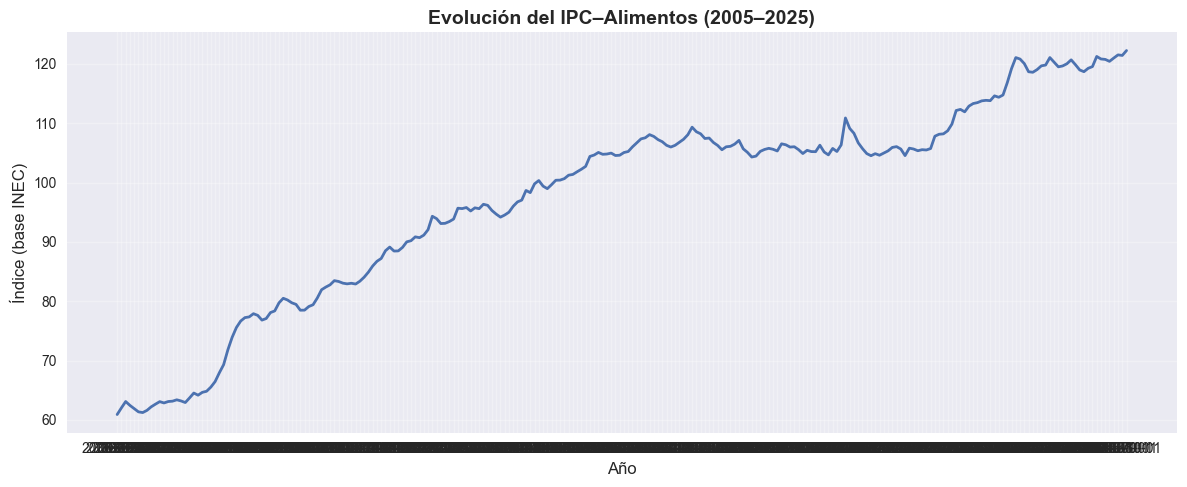

In [344]:
plt.figure(figsize=(12,5))
plt.plot(data.index, data['ipc_alimentos_index'], linewidth=2)
plt.title("Evolución del IPC–Alimentos (2005–2025)")
plt.xlabel("Año")
plt.ylabel("Índice (base INEC)")
plt.grid(True)
formato_anos(ax)
plt.show()


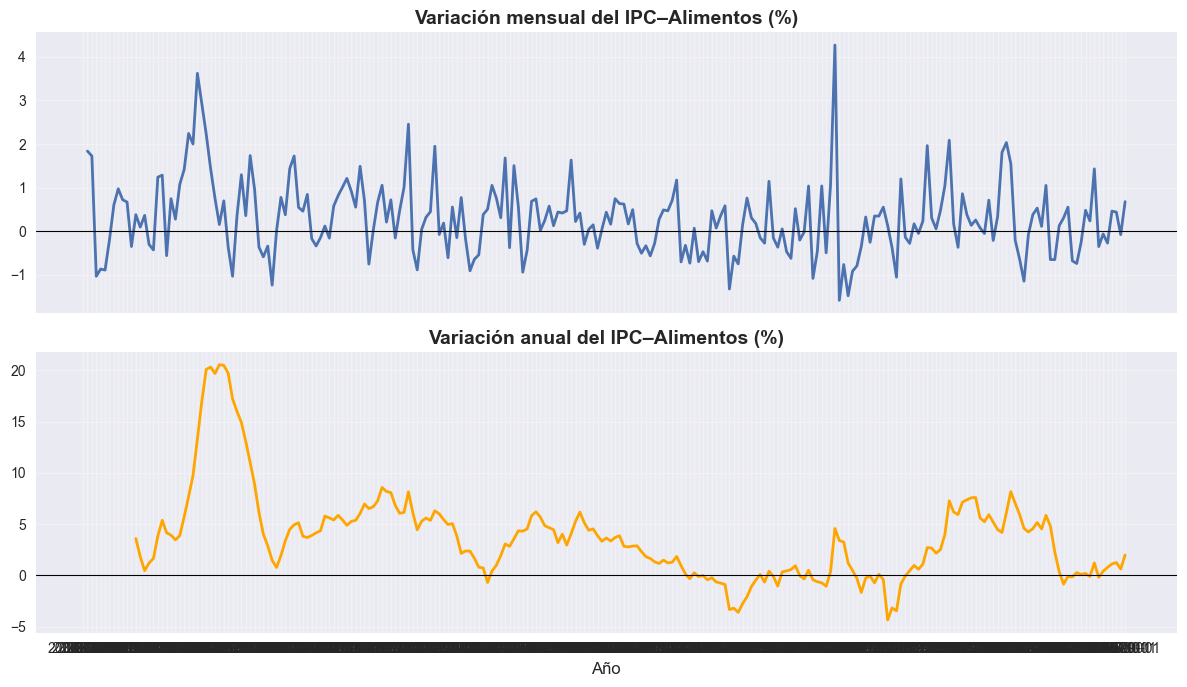

In [345]:
data["ipc_var_mensual"] = data["ipc_alimentos_index"].pct_change() * 100
data["ipc_var_anual"] = data["ipc_alimentos_index"].pct_change(12) * 100

fig, ax = plt.subplots(2, 1, figsize=(12,7), sharex=True)

ax[0].plot(data.index, data["ipc_var_mensual"])
ax[0].set_title("Variación mensual del IPC–Alimentos (%)")
ax[0].axhline(0, color="black", linewidth=0.8)
ax[0].grid(True)

ax[1].plot(data.index, data["ipc_var_anual"], color="orange")
ax[1].set_title("Variación anual del IPC–Alimentos (%)")
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].grid(True)

plt.xlabel("Año")
plt.tight_layout()
plt.show()


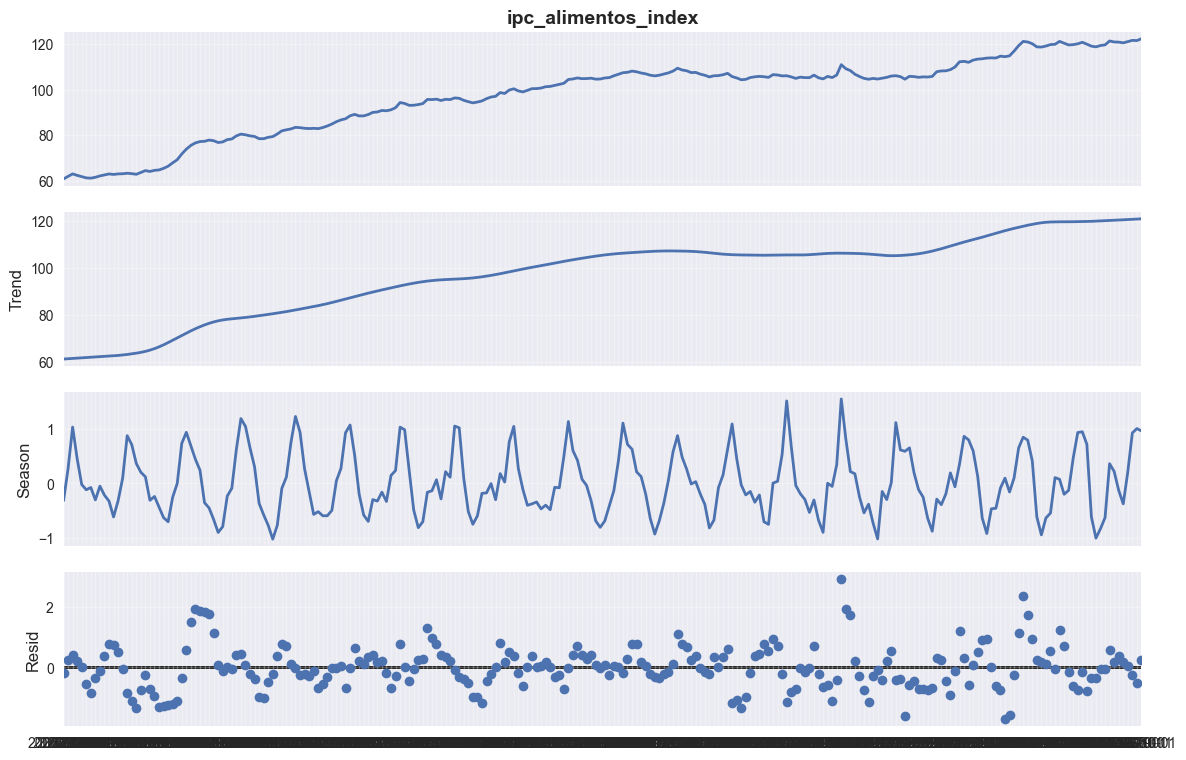

In [346]:
from statsmodels.tsa.seasonal import STL

stl = STL(data['ipc_alimentos_index'], period=12).fit()

fig = stl.plot()
fig.set_size_inches(12,8)
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24064\2698701925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette="viridis")


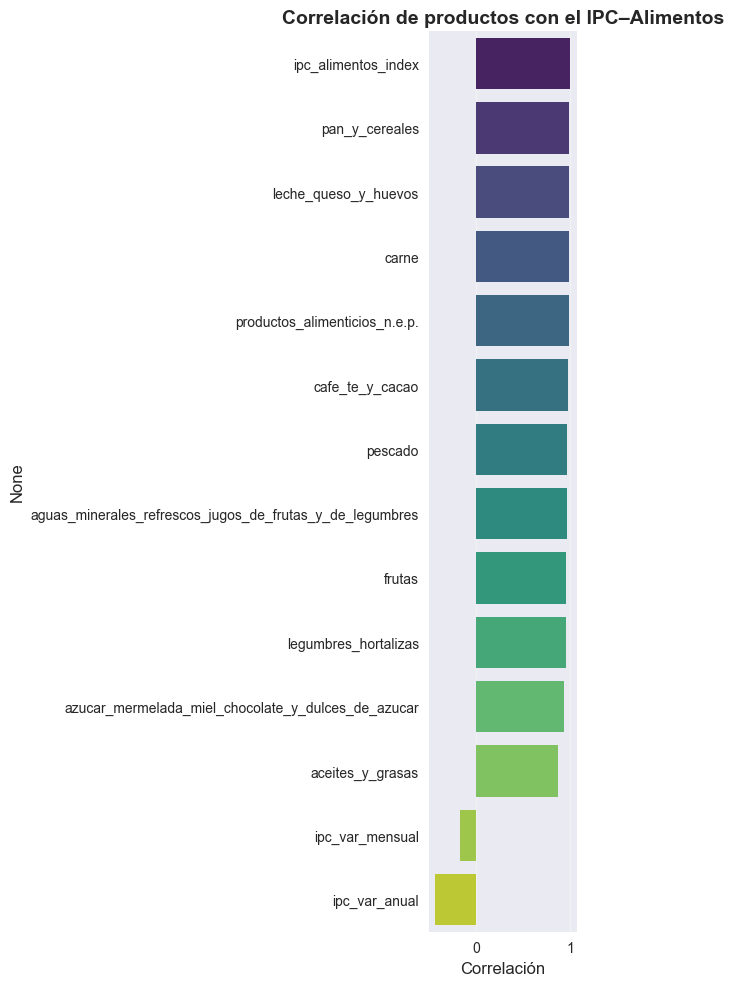

In [ ]:
corr = data.corr()['ipc_alimentos_index'].sort_values(ascending=False)
plt.figure(figsize=(6,10))
sns.barplot(x=corr.values, y=corr.index, palette="viridis")
plt.title("Correlación de productos con el IPC–Alimentos")
plt.xlabel("Correlación")
plt.show()


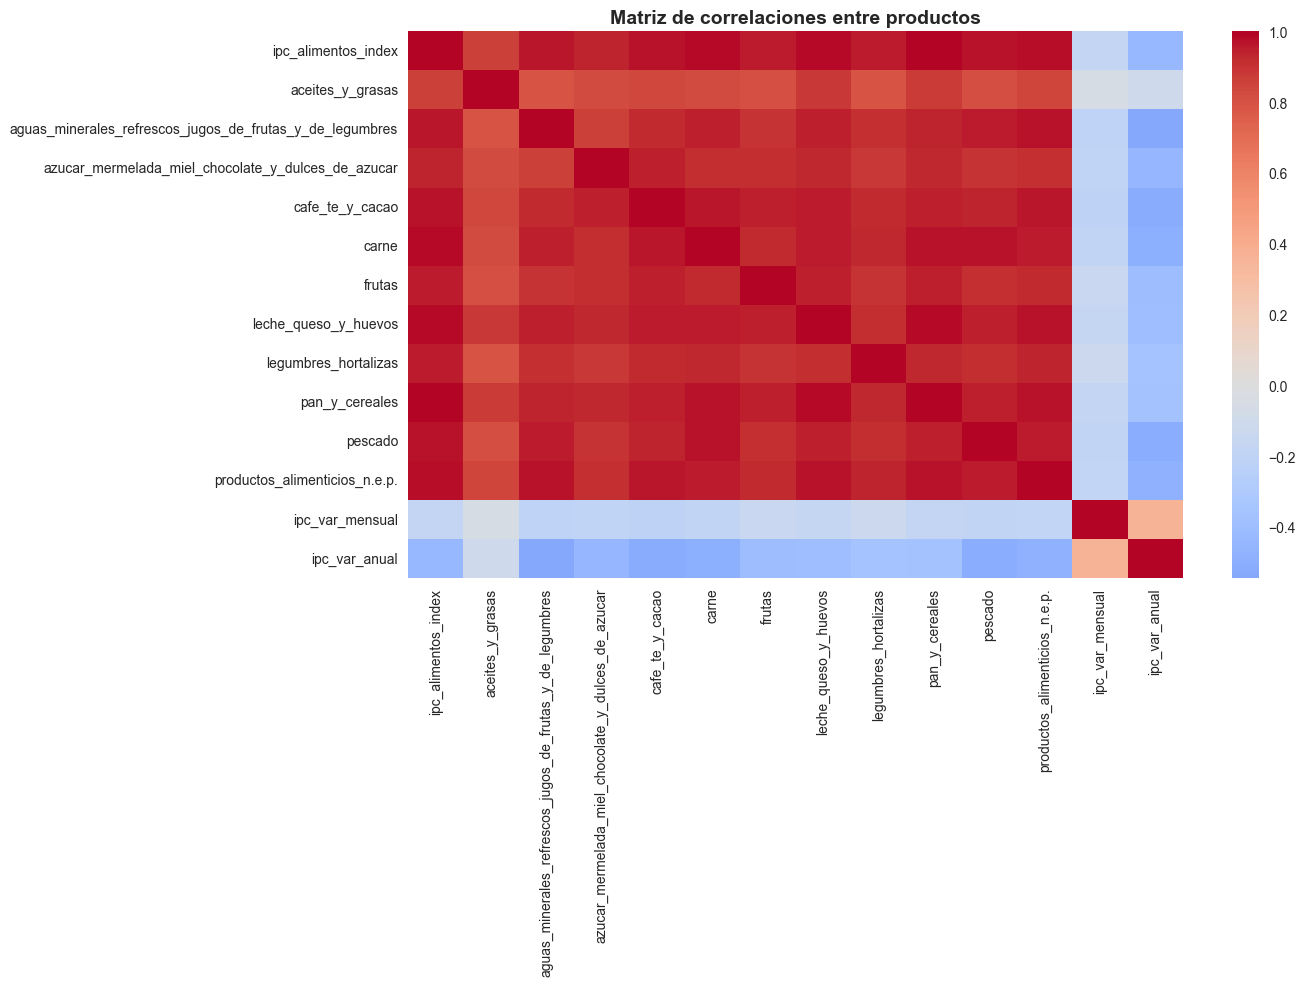

In [348]:
plt.figure(figsize=(14,10))
sns.heatmap(data.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones entre productos")
plt.show()


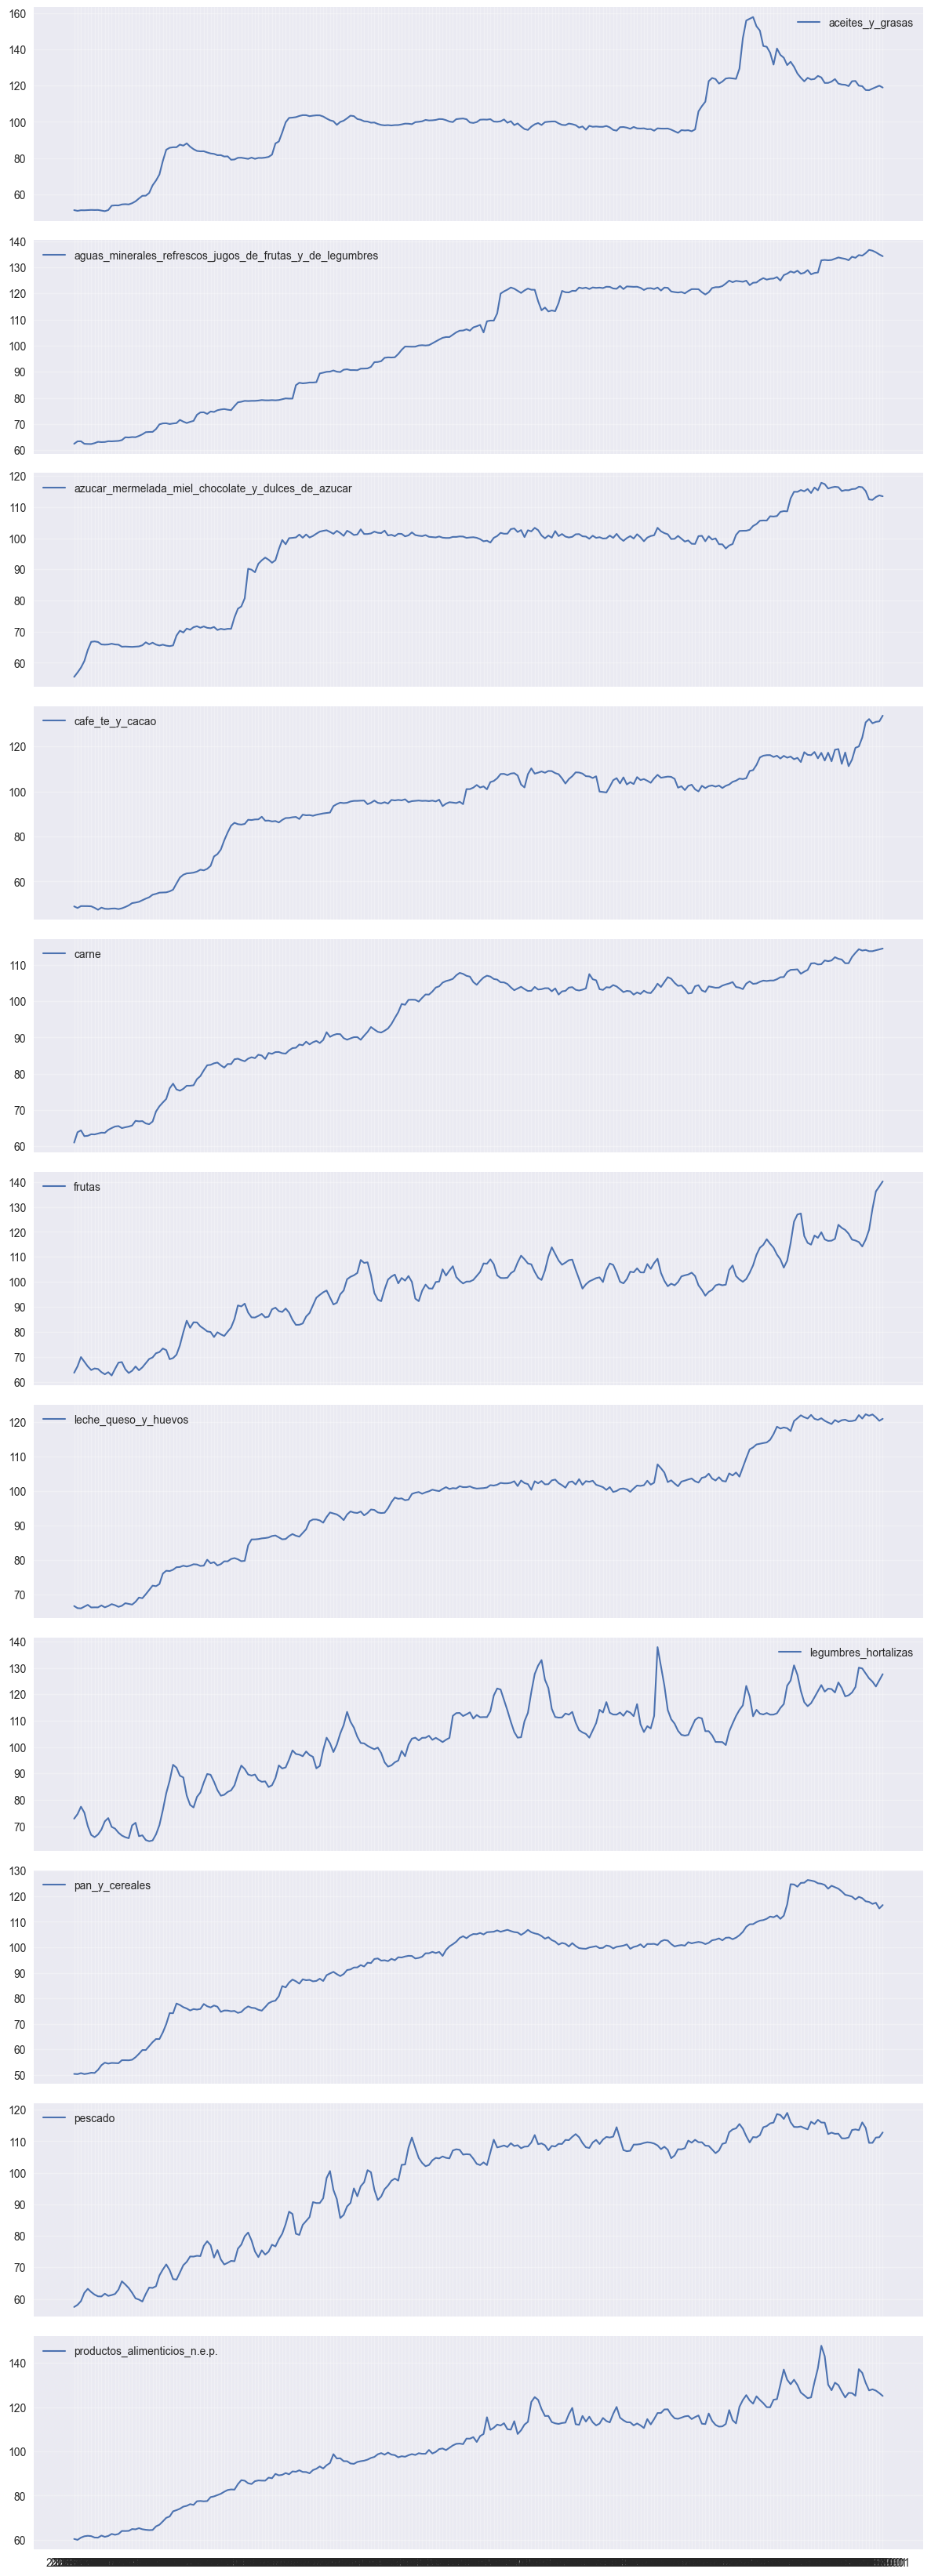

In [349]:
productos_cols = [col for col in data.columns if col != "ipc_alimentos_index" and "var" not in col]

fig, axes = plt.subplots(len(productos_cols), 1, figsize=(12,3*len(productos_cols)), sharex=True)


for ax, col in zip(axes, productos_cols):
    ax.plot(data.index, data[col], label=col, linewidth=1.5)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


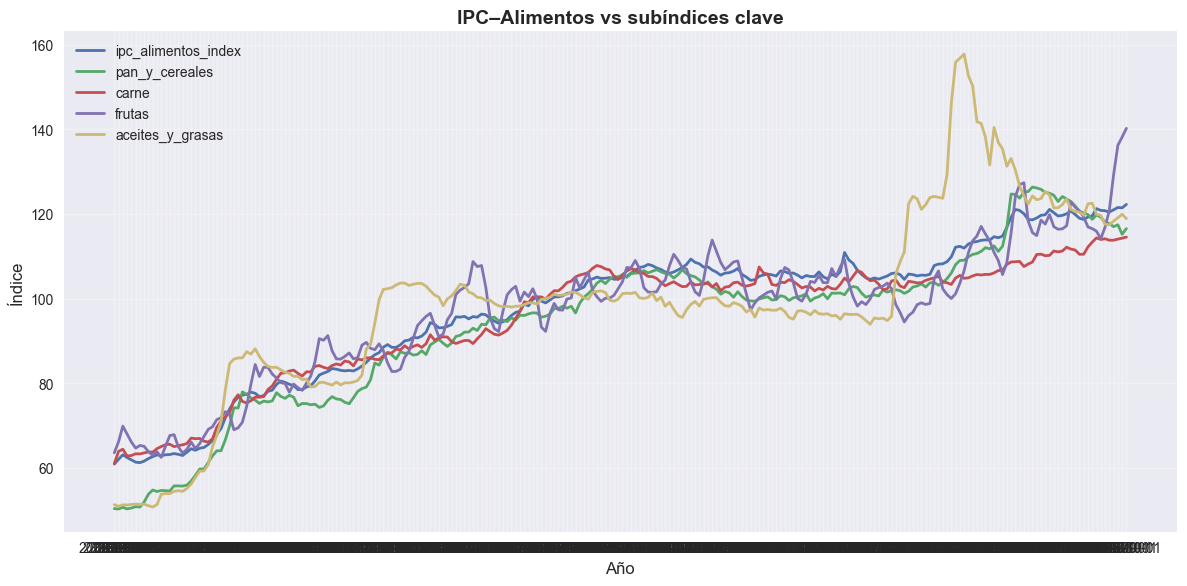

In [350]:
cols_clave = ["ipc_alimentos_index", "pan_y_cereales", "carne", "frutas", "aceites_y_grasas"]

plt.figure(figsize=(12,6))
for col in cols_clave:
    plt.plot(data.index, data[col], label=col)



plt.title("IPC–Alimentos vs subíndices clave")
plt.xlabel("Año")
plt.ylabel("Índice")
plt.legend()
plt.grid(True)
plt.show()

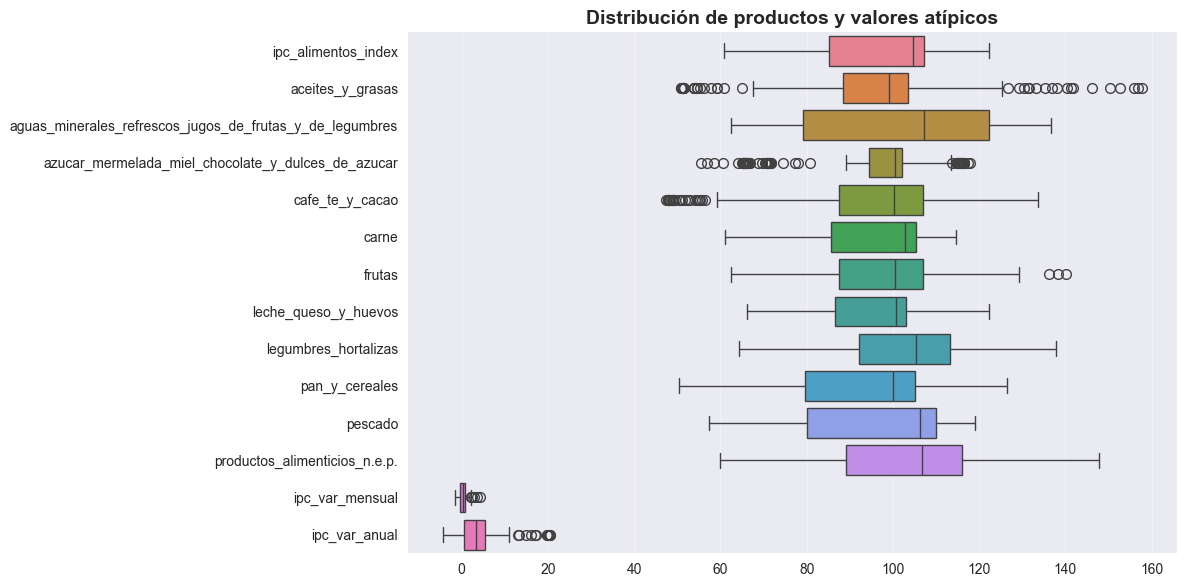

In [351]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data, orient='h')
plt.title("Distribución de productos y valores atípicos")
plt.show()


In [352]:
data["ipc_var_mensual"] = data["ipc_alimentos_index"].pct_change() * 100



In [353]:
var_mensual = data["ipc_var_mensual"].dropna()

promedio_mensual = var_mensual.mean()
volatilidad_mensual = var_mensual.std()

promedio_mensual, volatilidad_mensual


(np.float64(0.29794799552668544), np.float64(0.850118314308216))

In [354]:
print(f"Tasa de crecimiento mensual promedio: {promedio_mensual:.3f}%")
print(f"Volatilidad (desviación estándar) mensual: {volatilidad_mensual:.3f}%")


Tasa de crecimiento mensual promedio: 0.298%
Volatilidad (desviación estándar) mensual: 0.850%


In [355]:
data.index = pd.to_datetime(data.index)

In [356]:
import calendar
# Asegúrate de tener la variación mensual calculada
data["ipc_var_mensual"] = data["ipc_alimentos_index"].pct_change() * 100

# Crear columna "mes" (número) y, si quieres, etiqueta
data["mes_num"] = data.index.month
data["mes_nombre"] = data.index.month.map(lambda m: calendar.month_name[m])


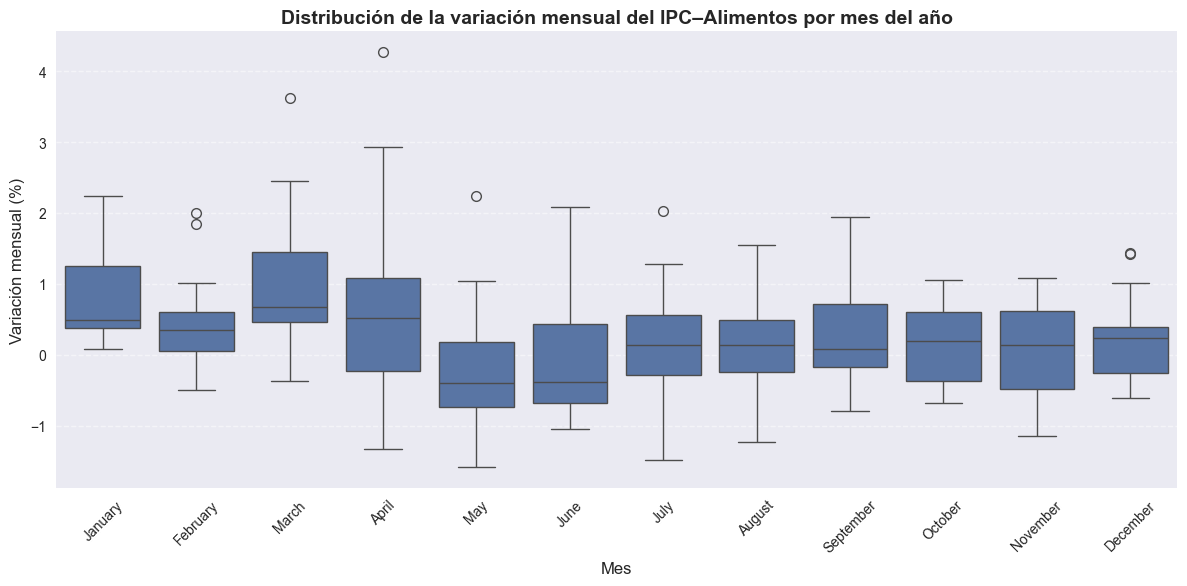

In [357]:
import seaborn as sns
import matplotlib.pyplot as plt
df_box = data.dropna(subset=["ipc_var_mensual"])

plt.figure(figsize=(12,6))
sns.boxplot(x="mes_nombre", y="ipc_var_mensual", data=df_box, order=[
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])
plt.title("Distribución de la variación mensual del IPC–Alimentos por mes del año")
plt.xlabel("Mes")
plt.ylabel("Variación mensual (%)")
plt.xticks(rotation=45)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


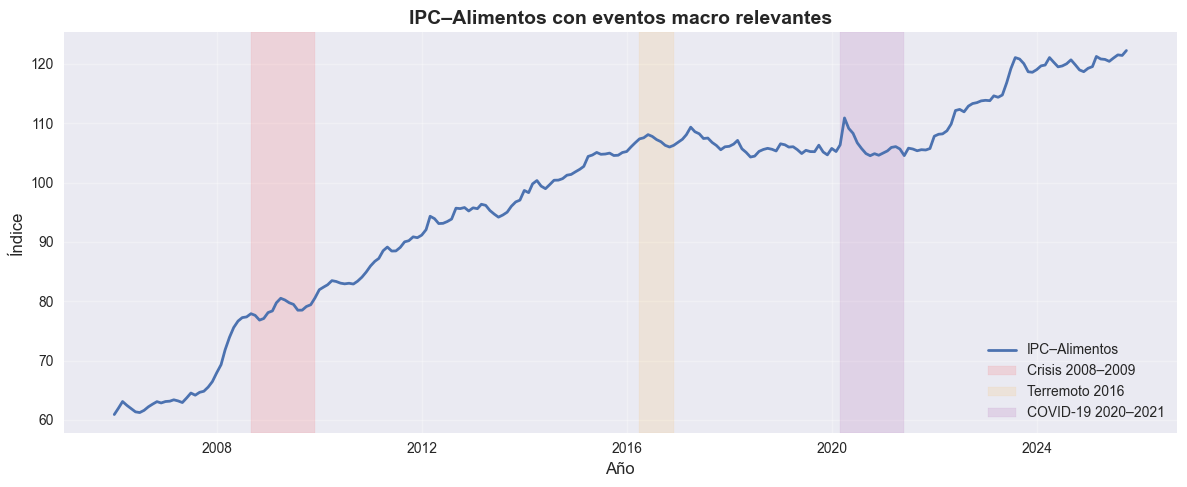

In [358]:
import matplotlib.pyplot as plt
import pandas as pd

# IMPORTANTE: Convertir índice a datetime primero
data.index = pd.to_datetime(data.index)

# Ahora crear la figura
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(data.index, data["ipc_alimentos_index"], label="IPC–Alimentos", linewidth=2)

# Crisis financiera 2008–2009
ax.axvspan(pd.to_datetime("2008-09-01"), pd.to_datetime("2009-12-01"),
           color="red", alpha=0.1, label="Crisis 2008–2009")

# Terremoto 2016
ax.axvspan(pd.to_datetime("2016-04-01"), pd.to_datetime("2016-12-01"),
           color="orange", alpha=0.1, label="Terremoto 2016")

# Pandemia COVID-19
ax.axvspan(pd.to_datetime("2020-03-01"), pd.to_datetime("2021-06-01"),
           color="purple", alpha=0.1, label="COVID-19 2020–2021")

ax.set_title("IPC–Alimentos con eventos macro relevantes")
ax.set_xlabel("Año")
ax.set_ylabel("Índice")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()